In [1]:
import sys

sys.path.append("../../BayesFlow")
sys.path.append("../")

import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pickle

import keras

import bayesflow as bf

from dmc import dmc_helpers
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


## Load Empirical Data

In [2]:
# load narrow and wide data
narrow_data = pd.read_csv('../empirical_data/experiment_data_narrow.csv')
wide_data = pd.read_csv('../empirical_data/experiment_data_wide.csv')

## Load Approximator

First, we load the approximator for the initial priors sdr estimated network and sample from the posterior seperately for each experimental condition:

In [3]:
network_name = 'initial_priors_sdr_estimated'

approximator = keras.saving.load_model("../training_checkpoints/" + network_name + ".keras")

/home/administrator/miniforge3/envs/bf_new/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 159 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Posterior Samples Narrow Condition

In [4]:
post_samples_narrow = dmc_helpers.fit_empirical_data(narrow_data, approximator=approximator, id_name='participant', rt='rt', accuracy='accuracy', congruency='congruency_num')

Sampling posteriors:  12%|█▎        | 9/72 [00:10<01:14,  1.18s/it]

[ID 808] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0026553881511746646. Please check the coding of congruency conditions.


Sampling posteriors: 100%|██████████| 72/72 [01:09<00:00,  1.04it/s]


## Posterior Samples Wide Condition

In [5]:
post_samples_wide = dmc_helpers.fit_empirical_data(wide_data, approximator=approximator, id_name='participant', rt='rt', accuracy='accuracy', congruency='congruency_num')

Sampling posteriors:  25%|██▌       | 18/72 [00:17<00:51,  1.04it/s]

[ID 275] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0018050166112955623. Please check the coding of congruency conditions.


Sampling posteriors:  38%|███▊      | 27/72 [00:29<00:58,  1.30s/it]

[ID 3988] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.005174194991055481. Please check the coding of congruency conditions.


Sampling posteriors:  39%|███▉      | 28/72 [00:30<00:52,  1.18s/it]

...

Sampling posteriors:  49%|████▊     | 35/72 [00:38<00:41,  1.11s/it]

[ID 5803] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0037004545454545346. Please check the coding of congruency conditions.


Sampling posteriors:  92%|█████████▏| 66/72 [01:06<00:05,  1.11it/s]

[ID 8704] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.010731384290243118. Please check the coding of congruency conditions.


Sampling posteriors: 100%|██████████| 72/72 [01:11<00:00,  1.01it/s]


## Standardized Mean Differences

After sampling from the posterior for both experimental conditions, we can compute the standardized mean differences as follows:

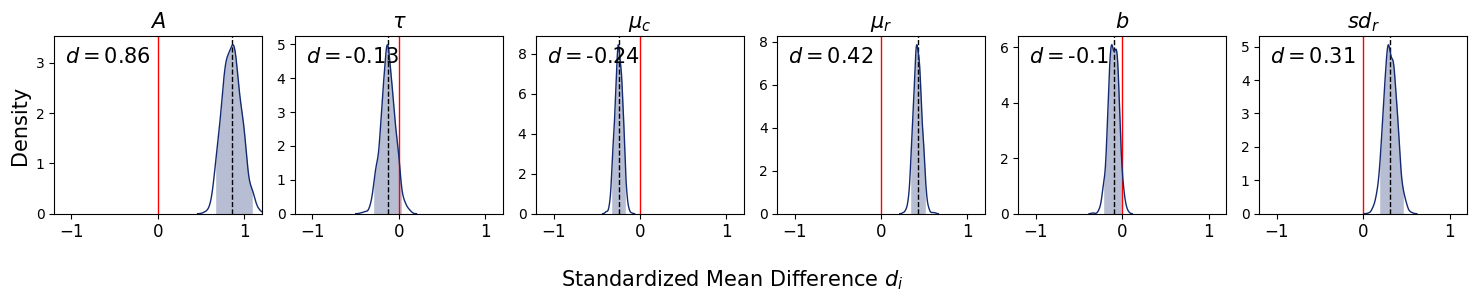

In [6]:
data, fig = dmc_helpers.smd_samples(post_samples_narrow, 
                                    post_samples_wide, 
                                    param_names=("A", "tau", "mu_c", "mu_r", "b", "sd_r"), 
                                    num_samples=1000, 
                                    id_name='participant', 
                                    hdi_color='white', 
                                    sharex=False)